# Project Definition

## Context

The COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) score is a statistically derived measure used to predict a defendant's risk of recidivism, or the likelihood of committing a new crime.

In practice, the COMPAS score is utilized at nearly every stage of the American legal system, with judges, prosecutors, and parole boards relying on it to inform high-stakes decisions. 

It promises to replace subjective human intuition with objective, data-driven insights. By providing a standardized risk assessment, it aims to reduce prison overcrowding and improve public safety.

## Motivation

One of our individual papers was heavily focused on data fairness. Another one touched a bit in that ballpark while studying different normalization strategies. Because of this we decided to explore further the intersection of model fairness and explainability. These two are important to be able to achieve an unbiased model, and we believe this dataset will allow us to develop better understanding of both.

## Data Set
The data contains the records of over 7,000 criminal defendants from Broward County, Florida.

### Source

- Originally found in this [kaggle post](https://www.kaggle.com/datasets/danofer/compass/data) 

- Traced back to [Propublica's repository](https://github.com/propublica/compas-analysis)

According to their [original study](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing):


ProPublica obtained the COMPAS scores for defendants booked between 2013 and 2014. They then mapped these scores to the public criminal records of the same individuals through April 2016 to determine if they actually re-offended (recidivated) within a two-year follow-up period.

The scores were generated by Northpointe's proprietary algorithm, which uses 137 features derived from a defendant's criminal history and their answers to a behavioral and psychological questionnaire.



### Limitations

ProPublica's statement about recedivism score realiability:
> When a full range of crimes were taken into account — including misdemeanors such as driving with an expired license — the algorithm was somewhat more accurate than a coin flip. Of those deemed likely to re-offend, 61 percent were arrested for any subsequent crimes within two years.

As stated before, the original algorithm uses 137. Trying to estimate COMPAS scores from this dataset may prove to be difficult since we only have 25-26 features. This lack of information may impact our model's performance. 

### Potencial bias

This dataset is most famous for the racial bias documented in [ProPublica's analysis](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm).

It concluded that the algorithm produced significant racial disparities that could not be explained by a defendant's criminal history, age, or gender. 

While the tool maintained similar overall accuracy across groups, it exhibited a different error pattern: 

- Nearly 2x as likely to falsely flag black defendants as high-risk compared to white defendants

- White defendants were more frequently mislabeled as low-risk.

Even after statistically isolating for prior offenses and recidivism, the study found that:

- Black defendants remained 77% more likely to be predicted as violent recidivists

- Black defendants are also 45% more likely to be predicted to commit any future crime

This suggestes the algorithm effectively acted as a proxy for race rather than a neutral predictor of safety.


## Our problem

We want to be able to determine a COMPAS score based on a defendant features. Making this a regression problem.

# Initial analysis

### Data Loading and Preparation

In [ ]:
# imports and dataset

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# adjust path if needed
path = "compas-scores-raw.csv"
df = pd.read_csv(path)

### Dataset Overview

In [ ]:
print(f"Dataset Shape: {df.shape}")
print(f"Count of Unique Individuals: {df['Person_ID'].nunique()}")

Dataset Shape: (60843, 28)
Count of Unique Individuals: 18610


### Missing Values

In [ ]:
print("\nNull or NAN counts:")
print(df.isnull().sum())


Null or NAN counts:
Person_ID                      0
AssessmentID                   0
Case_ID                        0
Agency_Text                    0
LastName                       0
FirstName                      0
MiddleName                 45219
Sex_Code_Text                  0
Ethnic_Code_Text               0
DateOfBirth                    0
ScaleSet_ID                    0
ScaleSet                       0
AssessmentReason               0
Language                       0
LegalStatus                    0
CustodyStatus                  0
MaritalStatus                  0
Screening_Date                 0
RecSupervisionLevel            0
RecSupervisionLevelText        0
Scale_ID                       0
DisplayText                    0
RawScore                       0
DecileScore                    0
ScoreText                     45
AssessmentType                 0
IsCompleted                    0
IsDeleted                      0
dtype: int64


### Variable Types Overview

In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
Person_ID                    int64
AssessmentID                 int64
Case_ID                      int64
Agency_Text                    str
LastName                       str
FirstName                      str
MiddleName                     str
Sex_Code_Text                  str
Ethnic_Code_Text               str
DateOfBirth                    str
ScaleSet_ID                  int64
ScaleSet                       str
AssessmentReason               str
Language                       str
LegalStatus                    str
CustodyStatus                  str
MaritalStatus                  str
Screening_Date                 str
RecSupervisionLevel          int64
RecSupervisionLevelText        str
Scale_ID                     int64
DisplayText                    str
RawScore                   float64
DecileScore                  int64
ScoreText                      str
AssessmentType                 str
IsCompleted                  int64
IsDeleted                    int64
dtype: 

### Categorical Variable Analysis

In [ ]:
exclude_vars = ['DateOfBirth', 'MiddleName', 'LastName', 'FirstName', 'Screening_Date']
categorical_vars = [col for col in df.select_dtypes(include=['object', 'category', 'str']).columns if col not in exclude_vars]
for col in categorical_vars:
    print(f"Col: {col}")
    print(f"Number of categories: {df[col].nunique()}")
    print(f"Percentage:")
    print(df[col].value_counts(normalize=True).mul(100).round(2))
    print()

Col: Agency_Text
Number of categories: 4
Percentage:
Agency_Text
PRETRIAL          67.55
Probation         31.32
DRRD               0.93
Broward County     0.20
Name: proportion, dtype: float64

Col: Sex_Code_Text
Number of categories: 2
Percentage:
Sex_Code_Text
Male      78.09
Female    21.91
Name: proportion, dtype: float64

Col: Ethnic_Code_Text
Number of categories: 9
Percentage:
Ethnic_Code_Text
African-American    44.41
Caucasian           35.80
Hispanic            14.37
Other                4.26
Asian                0.53
Native American      0.36
Arabic               0.12
African-Am           0.08
Oriental             0.06
Name: proportion, dtype: float64

Col: ScaleSet
Number of categories: 2
Percentage:
ScaleSet
Risk and Prescreen    96.39
All Scales             3.61
Name: proportion, dtype: float64

Col: AssessmentReason
Number of categories: 1
Percentage:
AssessmentReason
Intake    100.0
Name: proportion, dtype: float64

Col: Language
Number of categories: 2
Percentage:
Lan

### Numerical Variable Analysis

In [ ]:
numerical_vars = df.select_dtypes(include=['number']).columns
numerical_vars = [col for col in numerical_vars if 'ID' not in col and col not in ['IsCompleted', 'IsDeleted']]

print("\nNumerical Analysis (Distribution Stats):")
print(df[numerical_vars].describe().round(2))


Numerical Analysis (Distribution Stats):
       RecSupervisionLevel  RawScore  DecileScore
count             60843.00  60843.00     60843.00
mean                  1.63      5.08         3.57
std                   0.94     10.08         2.62
min                   1.00     -4.79        -1.00
25%                   1.00     -2.09         1.00
50%                   1.00     -0.71         3.00
75%                   2.00     14.00         5.00
max                   4.00     51.00        10.00



Skewness:
RecSupervisionLevel: 1.2727
RawScore: 1.0299
DecileScore: 0.8383


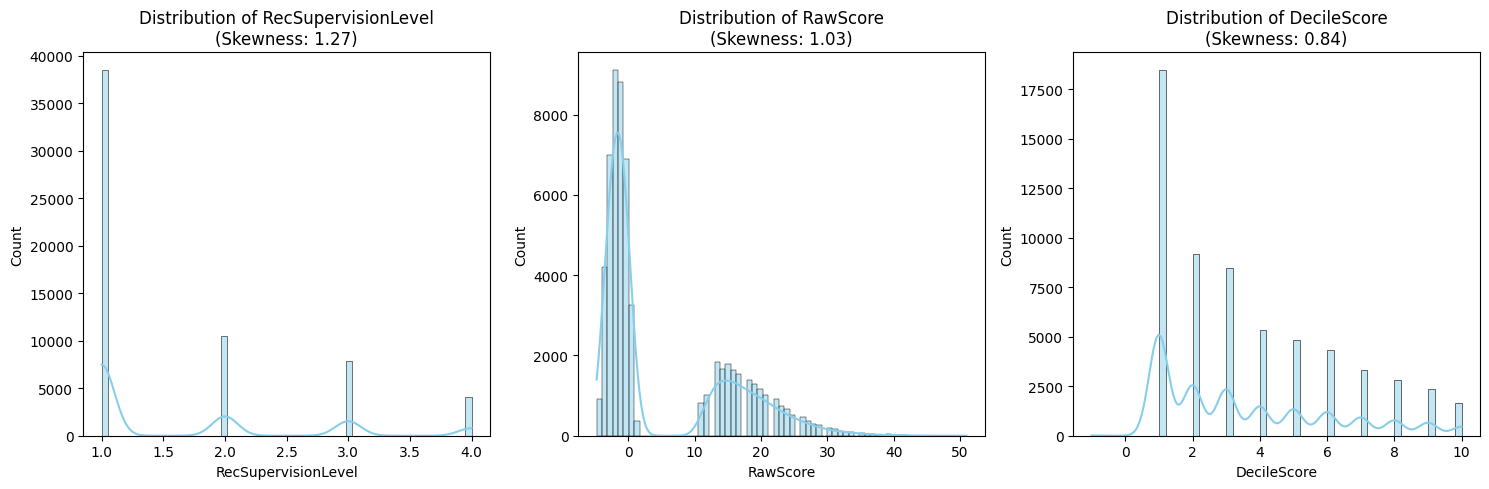

In [ ]:
print("\nSkewness:")
for col in numerical_vars:
    s = skew(df[col].dropna())
    print(f"{col}: {s:.4f}")

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_vars, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}\n(Skewness: {skew(df[col].dropna()):.2f})')
plt.tight_layout()
plt.show()